# 01 — N-State Markov Chain from Dirichlet

We follow the setup from the in-context learning literature: the transition
matrix is itself **random**, with each row drawn i.i.d. from a symmetric
Dirichlet distribution:

$$T_{i,\cdot} \sim \text{Dirichlet}(\alpha, \ldots, \alpha) \in \Delta^{N-1}, \quad i = 0,\ldots,N-1$$

The scalar $\alpha > 0$ controls how concentrated each row is:

| $\alpha$ | typical row | chain behaviour |
|----------|-------------|-----------------|
| $\ll 1$  | near one-hot | sticks to one state or teleports |
| $= 1$    | uniform on simplex (flat prior) | moderate mixing |
| $\gg 1$  | near $(1/N,\ldots,1/N)$ | rapid uniform mixing |

The stationary distribution is the row probability vector $\pi$ satisfying $\pi T = \pi$,
$\mathbf{1}^\top \pi = 1$.

Given a sampled $T$, we generate sequences of length `seq_len` using
`sample_sequences(T, n, seq_len, rng)`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from markov_chain import (
    sample_sequences,
    sample_transition_matrix,
    stationary_distribution,
)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Sample a transition matrix

In [2]:
n_states = 4
alpha = 1.0

T = sample_transition_matrix(n_states=n_states, alpha=alpha, rng=0)

print(f"Transition matrix T  (n_states={n_states}, alpha={alpha}):")
print(np.round(T, 3))
print()

row_sums = T.sum(axis=1)
assert np.allclose(row_sums, 1.0), f"Row sums off: {row_sums}"
print("Row sums:", np.round(row_sums, 10))
print("✓ All rows sum to 1")

Transition matrix T  (n_states=4, alpha=1.0):
[[0.395 0.592 0.012 0.001]
 [0.152 0.452 0.187 0.209]
 [0.232 0.498 0.27  0.   ]
 [0.533 0.017 0.251 0.199]]

Row sums: [1. 1. 1. 1.]
✓ All rows sum to 1


## Effect of $\alpha$

As $\alpha$ varies, the Dirichlet distribution places different amounts of
mass near the corners vs the centre of the simplex.  Below we draw one
transition matrix for each of three representative values.

In [3]:
for alpha_val in [0.1, 1.0, 5.0]:
    T_ex = sample_transition_matrix(n_states=4, alpha=alpha_val, rng=42)
    print(f"alpha = {alpha_val}")
    print(np.round(T_ex, 3))
    print()

alpha = 0.1
[[0.214 0.605 0.    0.181]
 [0.    0.004 0.973 0.023]
 [0.002 0.103 0.043 0.853]
 [0.606 0.004 0.    0.39 ]]

alpha = 1.0
[[0.325 0.315 0.322 0.038]
 [0.014 0.239 0.232 0.514]
 [0.035 0.458 0.031 0.477]
 [0.494 0.11  0.352 0.044]]

alpha = 5.0
[[0.25  0.303 0.231 0.216]
 [0.298 0.21  0.251 0.241]
 [0.3   0.188 0.344 0.167]
 [0.278 0.264 0.171 0.288]]



## Stationary distribution

For a fixed $T$ the stationary distribution is the row probability vector $\pi \in \mathbb{R}^N$ satisfying

$$\pi T = \pi, \qquad \mathbf{1}^\top \pi = 1$$

We compute it by solving $(T^\top - I)\pi = 0$ (the transpose form of the same equation) with the last equation replaced by the normalisation constraint.

In [4]:
pi = stationary_distribution(T)

print("Stationary distribution π:")
print(np.round(pi, 6))
print(f"sum = {pi.sum():.10f}")

residual = np.abs(pi @ T - pi).max()
print(f"max |π T - π| = {residual:.2e}")
assert residual < 1e-10
print("✓ π T = π confirmed")

Stationary distribution π:
[0.276757 0.446946 0.159008 0.117289]
sum = 1.0000000000
max |π T - π| = 1.67e-16
✓ π T = π confirmed


## Marginal state distribution over time

We start all sequences at **state 0** and track $P(X_t = s)$ as $t$ grows.

- **Empirical**: fraction of sequences in state $s$ at each time step $t$.  
- **Theoretical**: closed-form marginal $p_0\, T^t$, where $p_0 = e_0$.

Both heatmaps should converge to the stationary distribution $\pi$ (horizontal bands matching the bar chart below).


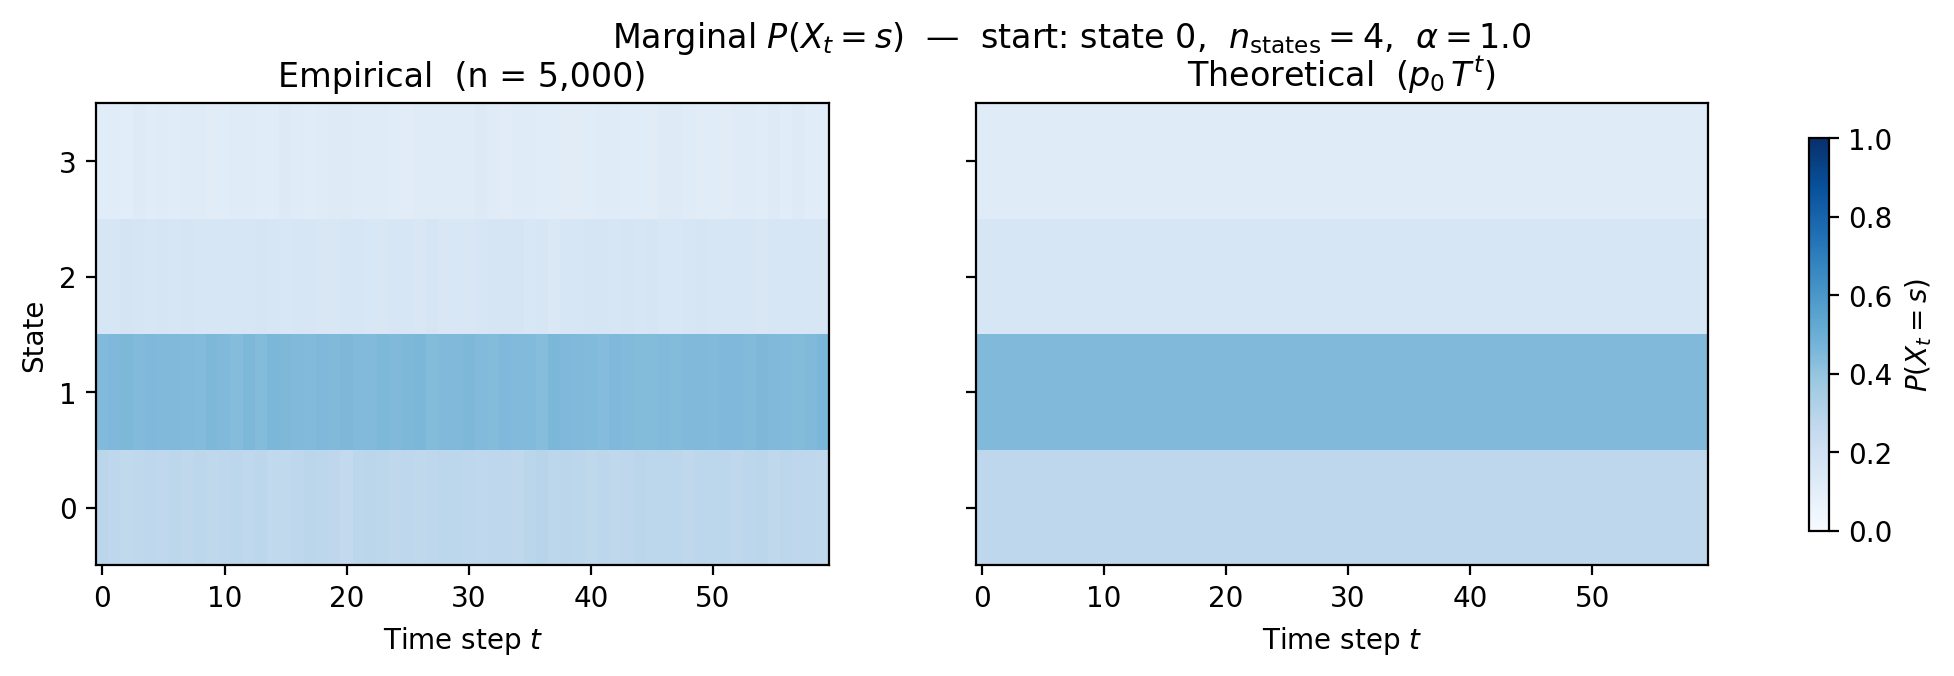

In [5]:
n_seqs = 5_000
seq_len_viz = 60
start_state = 0

pis = stationary_distribution(T)
seqs_viz = sample_sequences(T, n=n_seqs, seq_len=seq_len_viz, prior=pis, rng=42)

# Empirical marginal: fraction of sequences in state s at time t  shape (seq_len_viz, n_states)
emp_marginal = np.stack([(seqs_viz == s).mean(axis=0) for s in range(n_states)], axis=1)

# Theoretical marginal: p0 T^t  shape (seq_len_viz, n_states)
theo_marginal = np.empty((seq_len_viz, n_states))
p = pis.copy()
for t in range(seq_len_viz):
    theo_marginal[t] = p
    p = p @ T

fig, axes = plt.subplots(1, 2, figsize=(13, 3.0), sharey=True)
kw = dict(
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
    extent=[-0.5, seq_len_viz - 0.5, -0.5, n_states - 0.5],
    cmap="Blues",
)

axes[0].imshow(emp_marginal.T, **kw)
axes[0].set_title(f"Empirical  (n = {n_seqs:,})")
axes[0].set_xlabel("Time step $t$")
axes[0].set_ylabel("State")
axes[0].set_yticks(range(n_states))

im = axes[1].imshow(theo_marginal.T, **kw)
axes[1].set_title(r"Theoretical  ($p_0 \, T^t$)")
axes[1].set_xlabel("Time step $t$")
axes[1].set_yticks(range(n_states))

fig.colorbar(im, ax=axes, label=r"$P(X_t = s)$", shrink=0.85)
fig.suptitle(
    rf"Marginal $P(X_t = s)$  —  start: state {start_state},  "
    rf"$n_{{\mathrm{{states}}}}={n_states}$,  $\alpha={alpha}$",
    y=1.02,
)
# plt.tight_layout()
plt.show()

## Empirical verification

By the ergodic theorem the time-averaged visit frequency of each state
converges to $\pi$.  We run many long sequences and compare.

 State   Empirical   Analytical    |error|
     0      0.27736       0.27676     0.00060
     1      0.44682       0.44695     0.00012
     2      0.15844       0.15901     0.00057
     3      0.11738       0.11729     0.00009


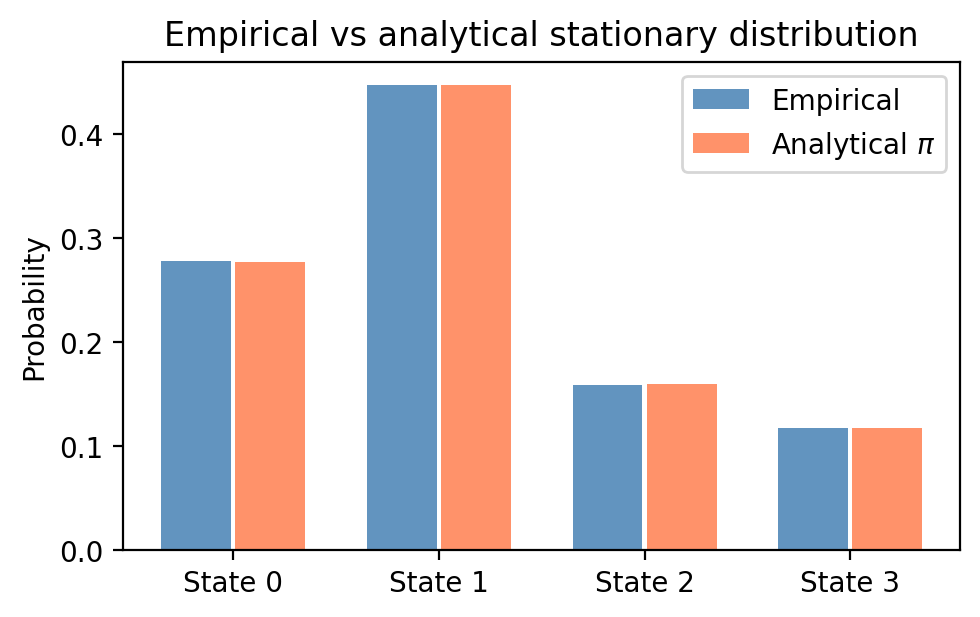

In [6]:
long_seqs = sample_sequences(T, n=5_000, seq_len=200, prior=pi, rng=1)
emp_pi = np.bincount(long_seqs.ravel(), minlength=n_states) / long_seqs.size

print(f"{'State':>6}  {'Empirical':>10}  {'Analytical':>11}  {'|error|':>9}")
for i in range(n_states):
    print(
        f"  {i:>4}   {emp_pi[i]:10.5f}   {pi[i]:11.5f}   {abs(emp_pi[i] - pi[i]):9.5f}"
    )

fig, ax = plt.subplots(figsize=(5, 3.2))
x = np.arange(n_states)
ax.bar(x - 0.18, emp_pi, 0.34, label="Empirical", color="steelblue", alpha=0.85)
ax.bar(x + 0.18, pi, 0.34, label=r"Analytical $\pi$", color="coral", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"State {i}" for i in range(n_states)])
ax.set_ylabel("Probability")
ax.set_title("Empirical vs analytical stationary distribution")
ax.legend()
plt.tight_layout()
plt.show()